<a href="https://colab.research.google.com/github/Kushen23/Statistical-Learning-e23290/blob/main/Bayesian_Estimations_for_Structural_Health_Monitoring_via_Bounded_Grid_Updates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.5 MB/s eta 0:00:00
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.3.0
    Uninstalling kaleido-1.3.0:
      Successfully uninstalled kaleido-1.3.0


# Bayesian Estimations for Structural Health Monitoring via Bounded Grid Updates

---

### 1. Prior Belief Boundaries

Before data collection begins, engineers assume the component is highly likely to be healthy, modeling this using a bounded Beta distribution as the initial prior: $\Theta \sim \text{Beta}(\alpha_0, \beta_0)$ with shape parameters $\alpha_0 = 8$ and $\beta_0 = 1.5$ over the physical domain $\theta \in (0, 1]$.

#### Analytical Expected Prior Efficiency
The expected prior stiffness efficiency $\mathbb{E}[\Theta^{(0)}]$ is evaluated analytically using the mean formula for a Beta distribution:

$$\mathbb{E}[\Theta^{(0)}] = \frac{\alpha_0}{\alpha_0 + \beta_0} = \frac{8}{8 + 1.5} = \frac{8}{9.5} \approx 0.8421$$

#### Physical Justification
This Beta(8, 1.5) prior serves as an appropriate representation for an engineered component assumed to be healthy because:
1. **Right-skewed density toward 1.0:** The mass of the distribution is heavily concentrated near $1.0$, representing high mechanical efficiency ($\approx 84.2\%$ expected health).
2. **Physical Boundary Enforcement:** It strictly limits $\theta \in (0, 1]$, preventing non-physical values such as negative stiffness or over-$100\%$ efficiency.

---

### 2. Structural Likelihood Formulation

At inspection step $k$, a continuous sensor measurement $y_k$ is modeled via non-linear physics with multiplicative log-normal measurement noise[cite: 1]:

$$y_k = \theta \cdot K_{\text{nominal}} \cdot e^{\epsilon_k}, \qquad \epsilon_k \sim \mathscr{N}(0, \sigma^2)$$[cite: 1]

Taking the natural logarithm yields:

$$\ln(y_k) = \ln(\theta \cdot K_{\text{nominal}}) + \epsilon_k \implies \ln(y_k) \sim \mathscr{N}\left(\ln(\theta \cdot K_{\text{nominal}}), \sigma^2\right)$$

#### Likelihood Contribution of a Single Observation
Using the log-normal probability density function, the likelihood contribution $L(y_k \mid \theta)$ of a single measurement $y_k$ given $\theta$ is[cite: 1]:

$$L(y_k \mid \theta) = \frac{1}{y_k \sigma \sqrt{2\pi}} \exp\left( -\frac{\left(\ln y_k - \ln(\theta \cdot K_{\text{nominal}})\right)^2}{2\sigma^2} \right)$$

#### Joint Likelihood Function for Running History
Assuming sensor measurements are conditionally independent given $\Theta = \theta$, the joint likelihood function for the running history vector $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)^T$ is[cite: 1]:

$$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^k L(y_i \mid \theta) = \left(\frac{1}{\sigma \sqrt{2\pi}}\right)^k \left(\prod_{i=1}^k \frac{1}{y_i}\right) \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^k \left( \ln y_i - \ln(\theta \cdot K_{\text{nominal}}) \right)^2 \right)$$

---

### 3. Mathematical Formulation of the Non-Conjugate Grid Update

An exact closed-form analytical solution for the posterior density $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$ does **not** exist because the Beta prior (belonging to the exponential family over $[0,1]$) and the Log-Normal likelihood (derived from logarithmic Gaussian transformation) do not form a conjugate prior-likelihood pair. The product of their algebraic functional forms cannot be simplified into a standard named probability distribution.

#### Recursive Updating Relationship
Under a sequential framework, the running posterior density at step $k$ is updated recursively using the prior state $f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$ and the new measurement $y_k$ up to a proportionality constant[cite: 1]:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$$

Expressing the full equality including the normalizing constant:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) = \frac{L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})}{\int_{0}^{1} L(y_k \mid s) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(s \mid \mathbf{y}^{(k-1)}) \, ds}$$[cite: 1]

---

### 4. Running Point Estimators

Because analytical integration is intractable, point estimators must be evaluated numerically over the bounded domain $\theta \in (0, 1]$[cite: 1]:

#### a. Running Posterior Mean ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$)
Minimizing expected squared-error loss, the Bayes estimate is the expected value of the current posterior distribution[cite: 1]:

$$\widehat{\theta}_{\mathrm{Bayes}}^{(k)} = \mathbb{E}\left[\Theta \mid \mathbf{Y}^{(k)} = \mathbf{y}^{(k)}\right] = \int_{0}^{1} \theta \cdot f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \, d\theta$$[cite: 1]

#### b. Running Maximum A Posteriori ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$)
The MAP estimate corresponds to the peak mode of the posterior distribution across the bounded domain[cite: 1]:

$$\widehat{\theta}_{\mathrm{MAP}}^{(k)} = \arg\max_{\theta \in (0, 1]} f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$$[cite: 1]

---

### 5. Algorithmic Grid Approximation and Normalization

To maintain the continuous posterior distribution computationally without conjugate shortcuts, we discretize the bounded domain $\theta \in [0.01, 1.0]$ into an equally spaced grid[cite: 1].

#### Step-by-Step Algorithmic Procedure:

1. **Grid Discretization:** Define $M$ discrete evaluation points over $[\theta_{\min}, \theta_{\max}] = [0.01, 1.0]$[cite: 1]:
   $$\theta_m = \theta_{\min} + (m-1)\Delta\theta, \qquad \Delta\theta = \frac{\theta_{\max} - \theta_{\min}}{M-1}, \qquad m = 1, 2, \dots, M$$[cite: 1]

2. **Prior Initialization:** Compute the initial prior array $\mathbf{P}^{(0)} = [f_\Theta^{(0)}(\theta_1), \dots, f_\Theta^{(0)}(\theta_M)]$ using the $\text{Beta}(8, 1.5)$ PDF and normalize using the composite trapezoidal rule[cite: 1]:
   $$Z_0 = \text{trapezoid}(\mathbf{P}^{(0)}, \boldsymbol{\theta}), \qquad \mathbf{P}^{(0)} \leftarrow \frac{\mathbf{P}^{(0)}}{Z_0}$$[cite: 1]

3. **Sequential Updating & Normalization (at step $k$):**
   * Compute likelihood array $\mathbf{L}_k = [L(y_k \mid \theta_1), \dots, L(y_k \mid \theta_M)]$ across the grid[cite: 1].
   * Compute unnormalized posterior array: $\tilde{\mathbf{P}}^{(k)} = \mathbf{P}^{(k-1)} \odot \mathbf{L}_k$ (element-wise multiplication)[cite: 1].
   * Integrate numerically to find the step normalizing constant:
     $$Z_k = \text{trapezoid}(\tilde{\mathbf{P}}^{(k)}, \boldsymbol{\theta}) = \sum_{m=1}^{M-1} \frac{\tilde{P}_m^{(k)} + \tilde{P}_{m+1}^{(k)}}{2} \Delta\theta$$[cite: 1]
   * Normalize: $\mathbf{P}^{(k)} = \frac{\tilde{\mathbf{P}}^{(k)}}{Z_k}$[cite: 1].

4. **Point Estimation Evaluation:**
   * **Bayes Estimate:** $\widehat{\theta}_{\mathrm{Bayes}}^{(k)} = \text{trapezoid}(\boldsymbol{\theta} \odot \mathbf{P}^{(k)}, \boldsymbol{\theta})$[cite: 1].
   * **MAP Estimate:** $\widehat{\theta}_{\mathrm{MAP}}^{(k)} = \theta_{m^*}$ where $m^* = \arg\max_{m} P_m^{(k)}$[cite: 1].

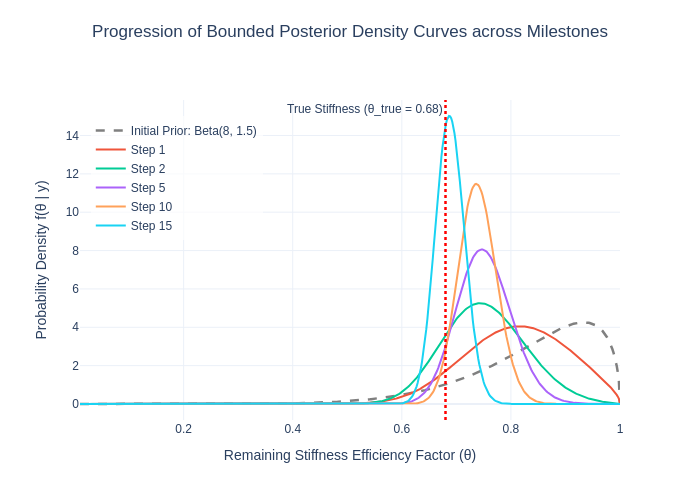

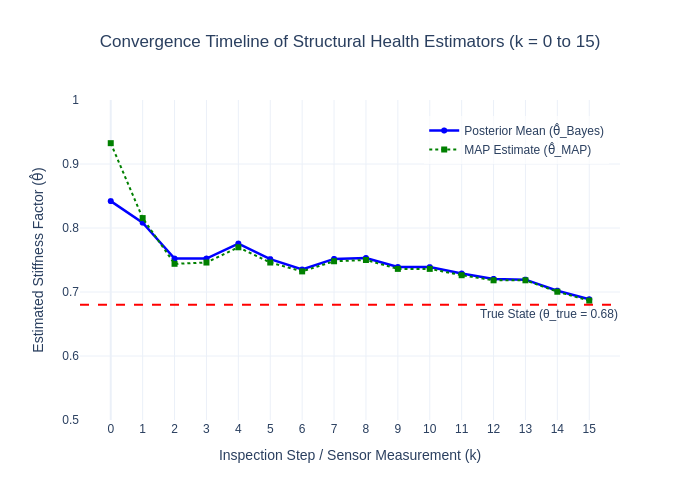

In [2]:
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# CONFIGURATION & SIMULATION SETUP (Task 6)
# =====================================================================
theta_true = 0.68       # True remaining stiffness efficiency factor (68%)
K_nominal = 50.0        # Baseline nominal stiffness (kN/mm)
sigma = 0.15            # Sensor noise standard deviation (log-space)
n_readings = 15         # Number of inspection time steps
grid_points = 500       # Resolution of bounded evaluation grid

# 1. Define bounded grid for theta in (0, 1]
theta_grid = np.linspace(0.01, 1.0, grid_points)

# 2. Initialize Prior State: Beta(8, 1.5)
prior_density = stats.beta.pdf(theta_grid, a=8, b=1.5)
prior_density /= np.trapezoid(prior_density, theta_grid)  # Normalize

# 3. Setup Tracking Lists
running_bayes = [np.trapezoid(theta_grid * prior_density, theta_grid)]
running_map = [theta_grid[np.argmax(prior_density)]]
steps = list(range(n_readings + 1))

# Milestone steps for capturing full posterior density curves
milestones = [0, 1, 2, 5, 10, 15]
posterior_curves = {0: prior_density.copy()}

# =====================================================================
# SEQUENTIAL UPDATE SIMULATION LOOP
# =====================================================================
current_posterior = prior_density.copy()

for k in range(1, n_readings + 1):
    # Simulate noisy sensor reading y_k from Log-Normal physics
    noise = np.random.normal(0, sigma)
    y_k = theta_true * K_nominal * np.exp(noise)

    # Evaluate Log-Normal Likelihood across the bounded theta grid
    # y_k ~ LogNormal(meanlog = ln(theta * K_nominal), sdlog = sigma)
    scale_params = theta_grid * K_nominal
    likelihood = stats.lognorm.pdf(y_k, s=sigma, scale=scale_params)

    # Bayesian Sequential Update: Unnormalized Posterior = Prior * Likelihood
    current_posterior = current_posterior * likelihood

    # Sequential Normalization via Trapezoidal Rule
    Z_k = np.trapezoid(current_posterior, theta_grid)
    current_posterior /= Z_k

    # Calculate Point Estimators
    bayes_est = np.trapezoid(theta_grid * current_posterior, theta_grid)
    map_est = theta_grid[np.argmax(current_posterior)]

    running_bayes.append(bayes_est)
    running_map.append(map_est)

    # Store milestone posterior curves
    if k in milestones:
        posterior_curves[k] = current_posterior.copy()

# =====================================================================
# VISUALIZATION 1: POSTERIOR DENSITY PROGRESSION CURVES
# =====================================================================
fig1 = go.Figure()

for step_k, density in posterior_curves.items():
    style = dict(dash='dash', width=2.5, color='gray') if step_k == 0 else dict(width=2)
    label = "Initial Prior: Beta(8, 1.5)" if step_k == 0 else f"Step {step_k}"

    fig1.add_trace(go.Scatter(
        x=theta_grid, y=density, mode='lines',
        name=label, line=style
    ))

fig1.add_vline(
    x=theta_true, line_dash="dot", line_color="red", line_width=2.5,
    annotation_text=f"True Stiffness (θ_true = {theta_true})", annotation_position="top left"
)

fig1.update_layout(
    title={
        'text': "Progression of Bounded Posterior Density Curves across Milestones",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Remaining Stiffness Efficiency Factor (θ)",
    yaxis_title="Probability Density f(θ | y)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.95, xanchor="left", x=0.02, bgcolor="rgba(255,255,255,0.7)")
)

fig1.show(renderer="png")

# =====================================================================
# VISUALIZATION 2: ESTIMATOR CONVERGENCE TIMELINE
# =====================================================================
fig2 = go.Figure()

fig2.add_hline(
    y=theta_true, line_dash="dash", line_color="red", line_width=2,
    annotation_text=f"True State (θ_true = {theta_true})", annotation_position="bottom right"
)

fig2.add_trace(go.Scatter(
    x=steps, y=running_bayes, mode='lines+markers',
    name='Posterior Mean (θ̂_Bayes)', line=dict(color='blue', width=2.5), marker=dict(size=6)
))

fig2.add_trace(go.Scatter(
    x=steps, y=running_map, mode='lines+markers',
    name='MAP Estimate (θ̂_MAP)', line=dict(color='green', width=2, dash='dot'), marker=dict(size=6, symbol='square')
))

fig2.update_layout(
    title={
        'text': "Convergence Timeline of Structural Health Estimators (k = 0 to 15)",
        'y': 0.93, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Inspection Step / Sensor Measurement (k)",
    yaxis_title="Estimated Stiffness Factor (θ̂)",
    xaxis=dict(tickmode='linear', tick0=0, dtick=1),
    yaxis=dict(range=[0.5, 1.0]),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.95, xanchor="right", x=0.98, bgcolor="rgba(255,255,255,0.7)")
)

fig2.show(renderer="png")